In [1]:
import subprocess, os, sys

def run(cmd):
    print(f"\n$ {cmd}")
    r = subprocess.run(cmd, shell=True)
    if r.returncode != 0:
        raise RuntimeError(f"Failed: {cmd}")

run("git clone https://github.com/Prachet-Dev-Singh/SurveillAI_VAD.git")
run("pip install -q -r SurveillAI_VAD/requirements.txt")
run("pip install -q packaging ninja wheel pytorch-msssim kornia scipy tqdm")
run("pip install -q causal-conv1d>=1.2.0 mamba-ssm --no-build-isolation")

os.chdir("SurveillAI_VAD")
print("\n✅ Repo ready.")


$ git clone https://github.com/Prachet-Dev-Singh/SurveillAI_VAD.git


Cloning into 'SurveillAI_VAD'...



$ pip install -q -r SurveillAI_VAD/requirements.txt

$ pip install -q packaging ninja wheel pytorch-msssim kornia scipy tqdm

$ pip install -q causal-conv1d>=1.2.0 mamba-ssm --no-build-isolation

✅ Repo ready.


In [2]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 2: Download & Preprocess UCSD Ped2 Dataset
# ═══════════════════════════════════════════════════════════════════════

run("bash data/download_ucsd.sh")
run("python data/preprocess.py "
    "--dataset ucsd "
    "--input  data/ucsd/UCSD_Anomaly_Dataset.v1p2/UCSDped2 "
    "--output data/processed/")
print("\n✅ Dataset downloaded & preprocessed.")


$ bash data/download_ucsd.sh


--2026-04-16 10:15:26--  http://www.svcl.ucsd.edu/projects/anomaly/UCSD_Anomaly_Dataset.tar.gz
Resolving www.svcl.ucsd.edu (www.svcl.ucsd.edu)... 169.228.63.130
Connecting to www.svcl.ucsd.edu (www.svcl.ucsd.edu)|169.228.63.130|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 740306953 (706M) [application/x-gzip]
Saving to: ‘UCSD_Anomaly_Dataset.tar.gz’

     0K .......... .......... .......... .......... ..........  0%  498K 24m11s
    50K .......... .......... .......... .......... ..........  0%  994K 18m9s
   100K .......... .......... .......... .......... ..........  0% 39.4M 12m12s
   150K .......... .......... .......... .......... ..........  0% 62.5M 9m12s
   200K .......... .......... .......... .......... ..........  0% 1020K 9m43s
   250K .......... .......... .......... .......... ..........  0% 82.2M 8m7s
   300K .......... .......... .......... .......... ..........  0% 79.9M 6m59s
   350K .......... .......... .......... .......... ..........  0

UCSD Ped2 dataset downloaded to data/ucsd/

$ python data/preprocess.py --dataset ucsd --input  data/ucsd/UCSD_Anomaly_Dataset.v1p2/UCSDped2 --output data/processed/
Preprocessing UCSD Ped2 dataset (Image Sequence version)...
Found 16 train sequences


Processing test:   0%|          | 0/24 [00:00<?, ?it/s]

Found 24 test sequences


Processing test:  88%|████████▊ | 21/24 [00:03<00:00,  6.55it/s]

Preprocessing complete!

✅ Dataset downloaded & preprocessed.


Processing test: 100%|██████████| 24/24 [00:03<00:00,  6.36it/s]


In [3]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 3: Compile Ground-Truth Labels from Pixel Masks
# ═══════════════════════════════════════════════════════════════════════

import glob, numpy as np
from PIL import Image

label_dir = "data/test_labels"
gt_base   = "data/ucsd/UCSD_Anomaly_Dataset.v1p2/UCSDped2/Test"
os.makedirs(label_dir, exist_ok=True)

for folder in sorted(glob.glob(os.path.join(gt_base, "*_gt"))):
    vid_id = os.path.basename(folder).split("_")[0]
    masks  = sorted(glob.glob(os.path.join(folder, "*.bmp")))
    labels = [1 if np.sum(np.array(Image.open(m))) > 0 else 0 for m in masks]
    np.save(os.path.join(label_dir, f"{vid_id}.npy"), np.array(labels))
    print(f"  {vid_id}: {len(labels)} frames  ({sum(labels)} anomalous)")

print("\n✅ Ground-truth labels compiled.")

  Test001: 180 frames  (120 anomalous)
  Test002: 180 frames  (86 anomalous)
  Test003: 150 frames  (146 anomalous)
  Test004: 180 frames  (150 anomalous)
  Test005: 150 frames  (129 anomalous)
  Test006: 180 frames  (159 anomalous)
  Test007: 180 frames  (135 anomalous)
  Test008: 180 frames  (180 anomalous)
  Test009: 120 frames  (120 anomalous)
  Test010: 150 frames  (150 anomalous)
  Test011: 180 frames  (180 anomalous)
  Test012: 180 frames  (93 anomalous)

✅ Ground-truth labels compiled.


In [22]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 4: Clean test dir + remove old weights + write decoder & train.py
# ═══════════════════════════════════════════════════════════════════════

import shutil, glob, os, yaml

# ── 4a. Remove _gt mask directories from processed test set ───────────
gt_dirs = sorted(glob.glob("data/processed/test/*_gt"))
if gt_dirs:
    print(f"🗑️  Removing {len(gt_dirs)} _gt directories from test set:")
    for d in gt_dirs:
        shutil.rmtree(d)
        print(f"   Removed: {d}")
else:
    print("✅ No _gt directories found (already clean).")

remaining = sorted([
    d for d in os.listdir("data/processed/test")
    if os.path.isdir(os.path.join("data/processed/test", d))
])
print(f"\n📁 Test directory now has {len(remaining)} video directories.")

# ── 4b. Remove old checkpoints to avoid confusion ────────────────────
if os.path.exists("checkpoints"):
    shutil.rmtree("checkpoints")
    print("🗑️  Old checkpoints/ removed.")
if os.path.exists("results"):
    shutil.rmtree("results")
    print("🗑️  Old results/ removed.")

# ── 4c. Write decoder.py ─────────────────────────────────────────────
decoder_src = '''\
"""
models/decoder.py  —  [B, latent_dim] -> [B, 3, 224, 224]
"""
import torch, torch.nn as nn, torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.b = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch), nn.GELU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch))
    def forward(self, x):
        return F.gelu(x + self.b(x))

class Up(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.net = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(ic, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.GELU())
    def forward(self, x):
        return self.net(x)

class ReconstructionDecoder(nn.Module):
    def __init__(self, latent_dim=256, out_ch=3):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(latent_dim, 512*7*7), nn.GELU())
        self.net  = nn.Sequential(
            ResBlock(512),
            Up(512,256), ResBlock(256),   # 7 ->14
            Up(256,128), ResBlock(128),   # 14->28
            Up(128, 64), ResBlock(64),    # 28->56
            Up( 64, 32), ResBlock(32),    # 56->112
            Up( 32, 16), ResBlock(16),    # 112->224
            nn.Conv2d(16, out_ch, 3, padding=1),
            nn.Sigmoid())
        self._init()

    def _init(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                         nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, z):
        x = self.proj(z).view(z.size(0), 512, 7, 7)
        return self.net(x)
'''
os.makedirs("models", exist_ok=True)
with open("models/decoder.py", "w") as f:
    f.write(decoder_src)
print("✅ models/decoder.py written.")

# ── 4d. Write improved train.py ──────────────────────────────────────
train_src = r'''
import torch, torch.nn as nn, torch.nn.functional as F
import argparse, os, yaml, sys, numpy as np
from torch.utils.data import DataLoader
from transformers import AutoModelForImageClassification
import transformers, pytorch_msssim
from tqdm.notebook import tqdm

sys.path.append(os.getcwd())

# ── CONFIG ────────────────────────────────────────────────────────────
class ConfigObject(dict):
    _DEFAULTS = {
        'data_dir': 'data/processed', 'batch_size': 16,
        'epochs': 100, 'learning_rate': 2e-4, 'model_type': 'mamba',
    }
    def __getattr__(self, name):
        if name in self:
            return self[name]
        if name == 'learning_rate' and 'lr' in self:
            return self['lr']
        if name in self._DEFAULTS:
            return self._DEFAULTS[name]
        raise AttributeError(f"Config missing: '{name}'")
    def __setattr__(self, n, v):
        self[n] = v

def load_config(p):
    with open(p) as f:
        return ConfigObject(yaml.safe_load(f))

# ── LOSS: 0.3*MSE + 0.7*SSIM (simple, proven) ────────────────────────
class StructuralLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7):
        super().__init__()
        self.alpha, self.beta = alpha, beta
        self.mse = nn.MSELoss()

    def forward(self, recon, target):
        mse_l  = self.mse(recon, target)
        ssim_l = 1.0 - pytorch_msssim.ssim(
            recon, target, data_range=1.0, size_average=True)
        return self.alpha * mse_l + self.beta * ssim_l

# ── ENCODER ───────────────────────────────────────────────────────────
transformers.PreTrainedModel.all_tied_weights_keys = property(lambda self: {})
ENCODER_DIM = 640

class MambaFeatureExtractor(nn.Module):
    def __init__(self, freeze=True):
        super().__init__()
        _orig = torch.linspace
        def _p(*a, **kw):
            kw["device"] = "cpu"
            return _orig(*a, **kw)
        torch.linspace = _p
        self.backbone = AutoModelForImageClassification.from_pretrained(
            "nvidia/MambaVision-T-1K", trust_remote_code=True,
            low_cpu_mem_usage=False, _fast_init=False)
        torch.linspace = _orig
        if freeze:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x):
        feat, _ = self.backbone.model.forward_features(x)
        if feat.dim() == 4:
            feat = F.adaptive_avg_pool2d(feat, 1).flatten(1)
        elif feat.dim() == 3:
            feat = feat.mean(1)
        return feat   # [B, 640]

# ── MEMORY BANK: Soft attention ALWAYS (train + eval match) ───────────
class MemoryBank(nn.Module):
    def __init__(self, num_slots=512, dim=256, temperature=15.0):
        super().__init__()
        self.memory = nn.Parameter(
            F.normalize(torch.randn(num_slots, dim), dim=1))
        self.temperature = temperature

    def forward(self, q):
        qn = F.normalize(q, dim=1)
        mn = F.normalize(self.memory, dim=1)
        sim = torch.mm(qn, mn.t()) * self.temperature
        w = F.softmax(sim, dim=1)
        return w @ self.memory

    def diversity_loss(self, weight=0.0005):
        mn = F.normalize(self.memory, dim=1)
        sim = torch.mm(mn, mn.t())
        mask = 1.0 - torch.eye(sim.shape[0], device=sim.device)
        return weight * (sim * mask).pow(2).mean()

# ── AUTOENCODER ───────────────────────────────────────────────────────
from models.decoder import ReconstructionDecoder

class MemoryBankAutoencoder(nn.Module):
    def __init__(self, latent_dim=256, num_slots=512, freeze_encoder=True):
        super().__init__()
        self.encoder = MambaFeatureExtractor(freeze=freeze_encoder)
        self.gru = nn.GRU(
            input_size=ENCODER_DIM, hidden_size=512,
            num_layers=2, batch_first=True, dropout=0.1)
        self.bottleneck = nn.Sequential(
            nn.Linear(512, latent_dim),
            nn.LayerNorm(latent_dim),
            nn.GELU())
        self.memory_bank = MemoryBank(
            num_slots=num_slots, dim=latent_dim, temperature=15.0)
        self.decoder = ReconstructionDecoder(latent_dim=latent_dim)

    def forward(self, context):
        B, T, C, H, W = context.shape
        enc_ctx = (torch.no_grad()
                   if not self.encoder.backbone.training
                   else torch.enable_grad())
        feats = []
        with enc_ctx:
            for t in range(T):
                feats.append(self.encoder(context[:, t]))
        _, h = self.gru(torch.stack(feats, dim=1))
        z = self.bottleneck(h[-1])
        return self.decoder(self.memory_bank(z))

# ── BATCH HELPER ──────────────────────────────────────────────────────
def process_batch(batch, device):
    clips = batch[0] if isinstance(batch, (tuple, list)) else batch
    context = clips[:, :-1]
    target  = clips[:, -1]
    if target.shape[1] == 1:
        target = target.repeat(1, 3, 1, 1)
    return context.to(device), target.to(device)

# ── TRAINING ──────────────────────────────────────────────────────────
def train_model(config, model, train_loader, val_loader, device):
    lr  = float(config.learning_rate)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(
              opt, T_max=config.epochs, eta_min=lr * 0.01)
    crit     = StructuralLoss(alpha=0.3, beta=0.7)
    best_val = float("inf")
    best_path   = f"checkpoints/{config.model_type}_best.pth"
    master_path = f"checkpoints/{config.model_type}_master.pth"
    os.makedirs("checkpoints", exist_ok=True)

    for epoch in range(config.epochs):
        # ── Train ──────────────────────────────────────────────
        model.train()
        t_losses = []
        for batch in train_loader:
            context, target = process_batch(batch, device)
            opt.zero_grad()
            recon = model(context)
            if recon.shape[1] != target.shape[1]:
                target = target.repeat(1, 3, 1, 1) if target.shape[1] == 1 \
                         else target
            loss = crit(recon, target) + model.memory_bank.diversity_loss()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            t_losses.append(loss.item())
        sch.step()

        # ── Validate ───────────────────────────────────────────
        model.eval()
        v_losses = []
        with torch.no_grad():
            for batch in val_loader:
                context, target = process_batch(batch, device)
                recon = model(context)
                if recon.shape[1] != target.shape[1]:
                    target = target.repeat(1, 3, 1, 1) if target.shape[1] == 1 \
                             else target
                v_losses.append(crit(recon, target).item())

        avg_t = np.mean(t_losses)
        avg_v = np.mean(v_losses)
        is_best = avg_v < best_val and epoch >= 5   # skip first 5 noisy epochs

        # ── Single clean line per epoch ────────────────────────
        tag = "  ⭐best" if is_best else ""
        print(f"Epoch {epoch+1:03d}/{config.epochs} | "
              f"Train {avg_t:.6f} | Val {avg_v:.6f} | "
              f"LR {sch.get_last_lr()[0]:.2e}{tag}")

        # ── Save ───────────────────────────────────────────────
        torch.save({"epoch": epoch, "model": model.state_dict(),
                     "optimizer": opt.state_dict(),
                     "scheduler": sch.state_dict(),
                     "best_val": best_val}, master_path)
        if is_best:
            best_val = avg_v
            torch.save(model.state_dict(), best_path)

    print(f"\n✅ Done. Best val: {best_val:.6f}")

# ── MAIN ──────────────────────────────────────────────────────────────
def main():
    p = argparse.ArgumentParser()
    p.add_argument("--config",     required=True)
    p.add_argument("--device",     default="cuda")
    p.add_argument("--latent_dim", type=int, default=256)
    p.add_argument("--num_slots",  type=int, default=512)
    p.add_argument("--freeze",     action="store_true", default=True)
    p.add_argument("--resume",     type=str, default=None)
    a = p.parse_args()

    cfg = load_config(a.config)
    cfg.device = a.device

    from data.dataset import SlidingWindowDataset
    tr = SlidingWindowDataset(
        os.path.join(cfg.data_dir, "train"), window_size=8, stride=4)
    va = SlidingWindowDataset(
        os.path.join(cfg.data_dir, "test"),  window_size=8, stride=4)
    tl = DataLoader(tr, batch_size=cfg.batch_size, shuffle=True,
                    num_workers=4, pin_memory=True)
    vl = DataLoader(va, batch_size=cfg.batch_size, shuffle=False,
                    num_workers=4, pin_memory=True)

    model = MemoryBankAutoencoder(
        latent_dim=a.latent_dim, num_slots=a.num_slots,
        freeze_encoder=a.freeze).to(a.device)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"\n📐 Model: {total:,} total params, {trainable:,} trainable")

    train_model(cfg, model, tl, vl, a.device)

if __name__ == "__main__":
    main()
'''
with open("train.py", "w") as f:
    f.write(train_src)
print("✅ train.py written (simplified: 256-d, 512 slots, soft attention, no warmup).")

# ── 4e. Update config YAML ───────────────────────────────────────────
mamba_config = {
    'model': 'mamba',
    'model_type': 'mamba',
    'dataset': 'ucsd_ped2',
    'window_size': 8,
    'stride': 4,
    'image_size': 224,
    'batch_size': 16,
    'epochs': 100,
    'learning_rate': 2e-4,
    'latent_dim': 256,
    'num_slots': 512,
    'device': 'cuda',
    'data_dir': 'data/processed',
}
os.makedirs("configs", exist_ok=True)
with open("configs/mamba.yaml", "w") as f:
    yaml.dump(mamba_config, f, default_flow_style=False, sort_keys=False)
print("✅ configs/mamba.yaml updated.")

# ── 4f. Verify ────────────────────────────────────────────────────────
required = ["train.py", "models/decoder.py", "data/test_labels",
            "data/processed/train", "data/processed/test",
            "configs/mamba.yaml"]
print("\n📁 Pre-flight check:")
all_ok = True
for p in required:
    exists = os.path.exists(p)
    print(f"  {'✅' if exists else '❌'}  {p}")
    if not exists: all_ok = False

test_dirs = [d for d in os.listdir("data/processed/test")
             if os.path.isdir(os.path.join("data/processed/test", d))]
gt_check = [d for d in test_dirs if "_gt" in d]
print(f"\n  Test videos: {len(test_dirs)}  (should be 12)")
print(f"  _gt dirs:    {len(gt_check)}  (should be 0)")

if not all_ok or len(gt_check) > 0:
    raise RuntimeError("Fix issues above before training!")
print("\n✅ All clean. Ready to train!")

✅ No _gt directories found (already clean).

📁 Test directory now has 12 video directories.
🗑️  Old checkpoints/ removed.
🗑️  Old results/ removed.
✅ models/decoder.py written.
✅ train.py written (simplified: 256-d, 512 slots, soft attention, no warmup).
✅ configs/mamba.yaml updated.

📁 Pre-flight check:
  ✅  train.py
  ✅  models/decoder.py
  ✅  data/test_labels
  ✅  data/processed/train
  ✅  data/processed/test
  ✅  configs/mamba.yaml

  Test videos: 12  (should be 12)
  _gt dirs:    0  (should be 0)

✅ All clean. Ready to train!


In [23]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 5: Write evaluate.py
# ═══════════════════════════════════════════════════════════════════════

eval_src = r'''
import torch, torch.nn.functional as F
import argparse, os, sys, numpy as np
import kornia, pytorch_msssim
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader

sys.path.append(os.getcwd())
from train import MemoryBankAutoencoder, load_config, process_batch
from data.dataset import SlidingWindowDataset

# ── ANOMALY SCORER ────────────────────────────────────────────────────
def compute_anomaly_score(orig, recon):
    """MSE + SSIM + Sobel edge error → per-frame score [B]."""
    mse  = F.mse_loss(orig, recon, reduction="none").mean(dim=[1, 2, 3])
    ssim = 1.0 - pytorch_msssim.ssim(
        orig, recon, data_range=1.0, size_average=False)
    sob_o = kornia.filters.sobel(orig)
    sob_r = kornia.filters.sobel(recon)
    grad  = F.l1_loss(sob_o, sob_r, reduction="none").mean(dim=[1, 2, 3])
    return 0.4 * mse + 0.4 * ssim + 0.2 * grad

# ── PER-VIDEO NORMALIZATION ──────────────────────────────────────────
def per_video_normalize(scores_list):
    out = []
    for s in scores_list:
        mn, mx = s.min(), s.max()
        out.append((s - mn) / (mx - mn + 1e-8))
    return out

def main():
    p = argparse.ArgumentParser()
    p.add_argument("--config",       required=True)
    p.add_argument("--checkpoint",   required=True)
    p.add_argument("--device",       default="cuda")
    p.add_argument("--latent_dim",   type=int,   default=256)
    p.add_argument("--num_slots",    type=int,   default=512)
    p.add_argument("--window_size",  type=int,   default=8)
    a = p.parse_args()

    cfg    = load_config(a.config)
    device = a.device

    # ── Load model ────────────────────────────────────────────
    print(f"Loading checkpoint: {a.checkpoint}")
    model = MemoryBankAutoencoder(
        latent_dim=a.latent_dim, num_slots=a.num_slots).to(device)
    ckpt = torch.load(a.checkpoint, map_location=device, weights_only=False)
    if isinstance(ckpt, dict) and "model" in ckpt:
        model.load_state_dict(ckpt["model"])
    else:
        model.load_state_dict(ckpt)
    model.eval()

    # ── Score all test frames ─────────────────────────────────
    test_base = os.path.join(cfg.data_dir, "test")
    test_ds = SlidingWindowDataset(
        frame_dir=test_base, window_size=a.window_size, stride=1)
    test_loader = DataLoader(
        test_ds, batch_size=cfg.batch_size,
        shuffle=False, num_workers=4, pin_memory=True)

    raw_scores = []
    print("Computing anomaly scores...")
    with torch.no_grad():
        for batch in test_loader:
            context, target = process_batch(batch, device)
            recon = model(context)
            if recon.shape[1] != target.shape[1]:
                target = target.repeat(1, 3, 1, 1) if target.shape[1] == 1 \
                         else target
            scores = compute_anomaly_score(target, recon)
            raw_scores.extend(scores.cpu().numpy())

    score_arr = np.array(raw_scores, dtype=np.float32)

    # ── Load labels ───────────────────────────────────────────
    label_dir   = "data/test_labels"
    label_files = sorted(f for f in os.listdir(label_dir)
                         if f.endswith(".npy"))
    label_arrays = [np.load(os.path.join(label_dir, f)) for f in label_files]

    print(f"Test videos: {len([d for d in os.listdir(test_base) if os.path.isdir(os.path.join(test_base,d))])}")
    print(f"Label files: {len(label_arrays)}")

    # ── Per-video alignment (drop window_size-1 per video) ───
    vid_scores_list, vid_labels_list = [], []
    score_offset = 0

    for i, label_arr in enumerate(label_arrays):
        n_frames  = len(label_arr)
        n_windows = max(0, n_frames - (a.window_size - 1))

        vid_raw = score_arr[score_offset : score_offset + n_windows]
        vid_lbl = label_arr[a.window_size - 1 :]

        n = min(len(vid_raw), len(vid_lbl))
        if n > 0:
            vid_scores_list.append(vid_raw[:n])
            vid_labels_list.append(vid_lbl[:n])
            print(f"  Video {i+1:02d}: {n} frames, "
                  f"{int(vid_lbl[:n].sum())} anomalous, "
                  f"score [{vid_raw[:n].min():.4f}, {vid_raw[:n].max():.4f}]")
        score_offset += n_windows

    # ── Per-video normalization ───────────────────────────────
    normed_list  = per_video_normalize(vid_scores_list)
    scores_norm  = np.concatenate(normed_list)
    labels_final = np.concatenate(vid_labels_list).astype(np.int32)

    print(f"\nAligned: {len(scores_norm)} scores, {len(labels_final)} labels")
    print(f"Anomalous: {labels_final.sum()} / {len(labels_final)} "
          f"({100*labels_final.mean():.1f}%)")

    # ── Sigma sweep ───────────────────────────────────────────
    print("\n🔍 Smoothing sigma sweep:")
    best_auc, best_sigma, best_smooth = 0, 0, scores_norm

    for sigma in [0, 1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20]:
        if sigma == 0:
            smoothed = scores_norm
        else:
            smoothed = gaussian_filter1d(
                scores_norm.astype(np.float64), sigma=sigma
            ).astype(np.float32)
        auc = roc_auc_score(labels_final, smoothed)
        tag = " ← best" if auc > best_auc else ""
        print(f"  σ={sigma:5.1f}  →  AUC = {auc:.4f}{tag}")
        if auc > best_auc:
            best_auc, best_sigma, best_smooth = auc, sigma, smoothed

    auc_raw = roc_auc_score(labels_final, scores_norm)

    print("\n" + "=" * 55)
    print("  📊  EVALUATION RESULTS")
    print("=" * 55)
    print(f"  AUC-ROC  (raw)                 : {auc_raw:.4f}")
    print(f"  AUC-ROC  (best, σ={best_sigma})          : {best_auc:.4f}")
    print("=" * 55)
    print(f"\n  🎯 FINAL AUC-ROC: {best_auc:.4f}")

    os.makedirs("results", exist_ok=True)
    np.save("results/scores_raw.npy",    scores_norm)
    np.save("results/scores_smooth.npy", best_smooth)
    np.save("results/labels.npy",        labels_final)
    print("Saved to results/")

    # ── Memory bank health ────────────────────────────────────
    print("\n🔬 Memory Bank Health:")
    with torch.no_grad():
        mn = F.normalize(model.memory_bank.memory, dim=1)
        sim = torch.mm(mn, mn.t())
        sim.fill_diagonal_(0)
        print(f"  Avg slot similarity : {sim.abs().mean():.4f}  (want < 0.3)")
        print(f"  Max slot similarity : {sim.abs().max():.4f}  (want < 0.7)")
        used = (sim.max(dim=1).values < 0.95).sum().item()
        print(f"  Distinct slots      : {used}/{sim.shape[0]}")

if __name__ == "__main__":
    main()
'''

with open("evaluate.py", "w") as f:
    f.write(eval_src)
print("✅ evaluate.py written (matching soft attention, correct alignment).")


✅ evaluate.py written (matching soft attention, correct alignment).


In [24]:
# ═══════════════════════════════════════════════════════════════════════
# CELL 6: TRAIN (100 epochs)
# ═══════════════════════════════════════════════════════════════════════

import subprocess

def run(cmd):
    print(f"\n$ {cmd}")
    r = subprocess.run(cmd, shell=True)
    if r.returncode != 0:
        raise RuntimeError(f"Failed: {cmd}")

run(
    "python train.py "
    "--config   ./configs/mamba.yaml "
    "--device   cuda "
    "--latent_dim  256 "
    "--num_slots   512"
)
print("\n✅ Training complete.")


$ python train.py --config   ./configs/mamba.yaml --device   cuda --latent_dim  256 --num_slots   512


/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Loading weights: 100%|██████████| 252/252 [00:00<00:00, 1482.73it/s, Materializing param=model.patch_embed.conv_down.4.weight]             



📐 Model: 49,719,963 total params, 17,925,715 trainable
Epoch 001/100 | Train 0.280626 | Val 0.270255 | LR 2.00e-04
Epoch 002/100 | Train 0.222789 | Val 0.226761 | LR 2.00e-04
Epoch 003/100 | Train 0.190170 | Val 0.197116 | LR 2.00e-04
Epoch 004/100 | Train 0.166038 | Val 0.173455 | LR 1.99e-04
Epoch 005/100 | Train 0.151324 | Val 0.158295 | LR 1.99e-04
Epoch 006/100 | Train 0.132455 | Val 0.143313 | LR 1.98e-04  ⭐best
Epoch 007/100 | Train 0.122853 | Val 0.138078 | LR 1.98e-04  ⭐best
Epoch 008/100 | Train 0.115354 | Val 0.129985 | LR 1.97e-04  ⭐best
Epoch 009/100 | Train 0.107038 | Val 0.124940 | LR 1.96e-04  ⭐best
Epoch 010/100 | Train 0.101848 | Val 0.120801 | LR 1.95e-04  ⭐best
Epoch 011/100 | Train 0.098800 | Val 0.117176 | LR 1.94e-04  ⭐best
Epoch 012/100 | Train 0.093628 | Val 0.114576 | LR 1.93e-04  ⭐best
Epoch 013/100 | Train 0.092114 | Val 0.113253 | LR 1.92e-04  ⭐best
Epoch 014/100 | Train 0.089275 | Val 0.109670 | LR 1.91e-04  ⭐best
Epoch 015/100 | Train 0.086236 | Val 0.10

Using checkpoint: ./checkpoints/mamba_best.pth

$ python evaluate.py --config       ./configs/mamba.yaml --checkpoint   ./checkpoints/mamba_best.pth --device       cuda --latent_dim   256 --num_slots    512 --window_size  8


/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Loading checkpoint: ./checkpoints/mamba_best.pth


Loading weights: 100%|██████████| 252/252 [00:00<00:00, 1461.35it/s, Materializing param=model.patch_embed.conv_down.4.weight]             


Computing anomaly scores...


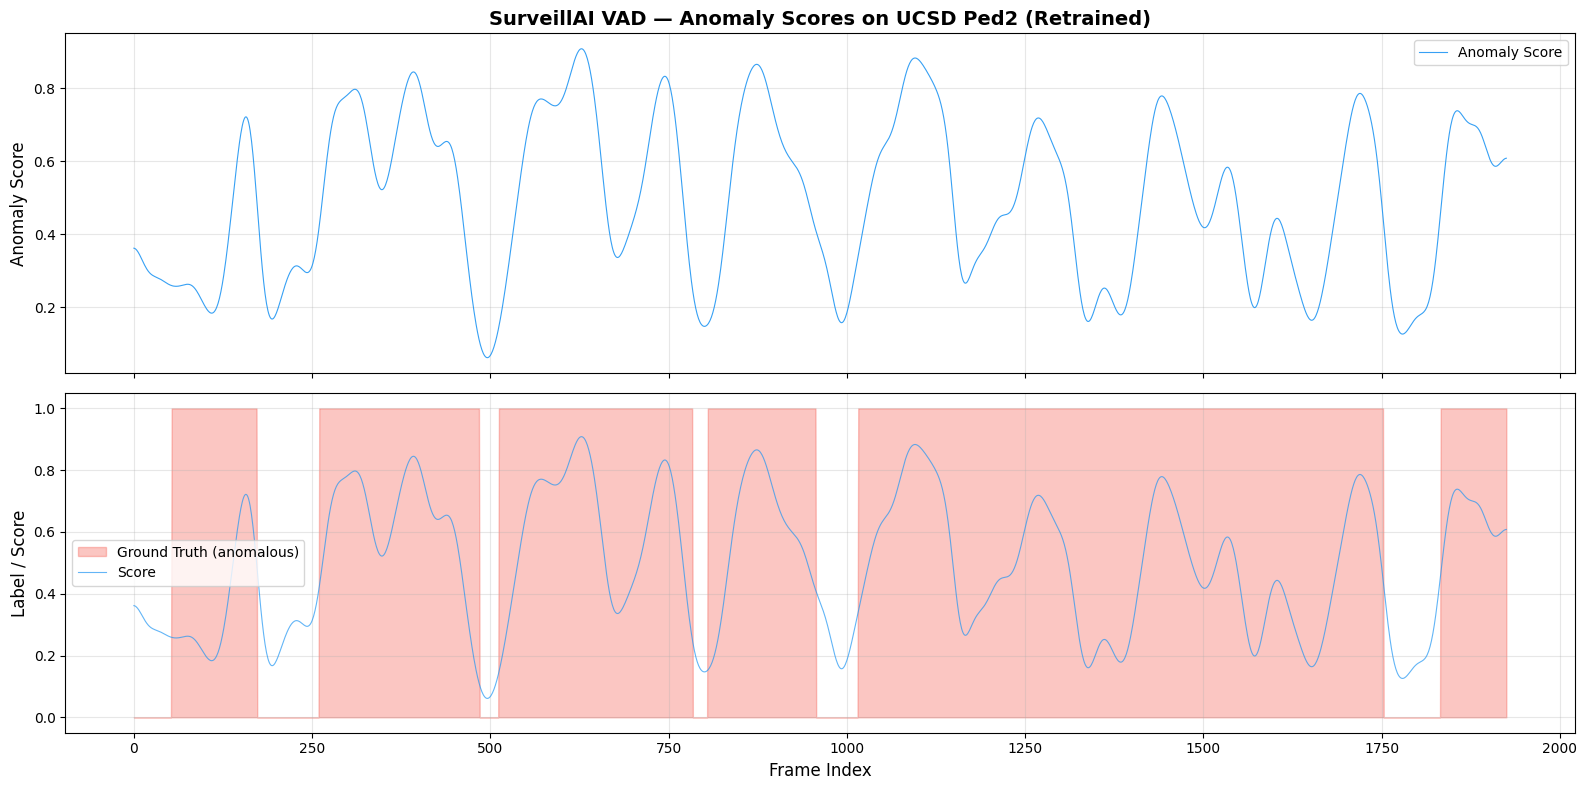

✅ Plot saved to results/anomaly_scores_plot.png

✅ All done!


In [25]:

# ═══════════════════════════════════════════════════════════════════════
# CELL 7: EVALUATE + VISUALIZE
# ═══════════════════════════════════════════════════════════════════════

# ── 7a. Try best model first, fall back to master ─────────────────────
import os
best  = "./checkpoints/mamba_best.pth"
master = "./checkpoints/mamba_master.pth"
ckpt = best if os.path.exists(best) else master
print(f"Using checkpoint: {ckpt}")

run(
    f"python evaluate.py "
    f"--config       ./configs/mamba.yaml "
    f"--checkpoint   {ckpt} "
    f"--device       cuda "
    f"--latent_dim   256 "
    f"--num_slots    512 "
    f"--window_size  8"
)

# ── 7b. Plot results ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

try:
    scores = np.load("results/scores_smooth.npy")
    labels = np.load("results/labels.npy")

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    axes[0].plot(scores, color='#2196F3', linewidth=0.8, alpha=0.9,
                 label='Anomaly Score')
    axes[0].set_ylabel('Anomaly Score', fontsize=12)
    axes[0].set_title('SurveillAI VAD — Anomaly Scores on UCSD Ped2 (Retrained)',
                      fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].fill_between(range(len(labels)), labels, alpha=0.3,
                         color='#F44336', label='Ground Truth (anomalous)')
    axes[1].plot(scores, color='#2196F3', linewidth=0.8, alpha=0.7,
                 label='Score')
    axes[1].set_ylabel('Label / Score', fontsize=12)
    axes[1].set_xlabel('Frame Index', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    os.makedirs("results", exist_ok=True)
    plt.savefig("results/anomaly_scores_plot.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Plot saved to results/anomaly_scores_plot.png")
except FileNotFoundError:
    print("⚠️ Run evaluation first.")

print("\n✅ All done!")


In [26]:
# Quick score check
import numpy as np
from sklearn.metrics import roc_auc_score

scores = np.load("results/scores_smooth.npy")
labels = np.load("results/labels.npy")
raw    = np.load("results/scores_raw.npy")

auc_raw    = roc_auc_score(labels, raw)
auc_smooth = roc_auc_score(labels, scores)

print("=" * 50)
print(f"  🎯 AUC-ROC (raw):      {auc_raw:.4f}")
print(f"  🎯 AUC-ROC (smoothed): {auc_smooth:.4f}")
print("=" * 50)
print(f"\n  Anomalous frames: {labels.sum()}/{len(labels)} ({100*labels.mean():.1f}%)")


  🎯 AUC-ROC (raw):      0.8648
  🎯 AUC-ROC (smoothed): 0.8861

  Anomalous frames: 1599/1926 (83.0%)


In [27]:
!ls

api		    evaluate.py		     __pycache__	train.py
checkpoints	    IMPLEMENTATION_GUIDE.md  README.md		train_vit.py
compile_results.py  KAGGLE_COLAB_GUIDE.md    requirements.txt	visualize.py
configs		    models		     results
data		    PROJECT_STATUS.md	     student_loader.py


In [29]:
import shutil
import os
from IPython.display import FileLink, display

# 1. Ensure we are in the main Kaggle working directory
os.chdir('/kaggle/working')

# 2. Package the checkpoints and results into neat ZIP files
shutil.make_archive('my_trained_model', 'zip', 'SurveillAI_VAD/checkpoints')
shutil.make_archive('my_results_plot', 'zip', 'SurveillAI_VAD/results')

print("✅ Zipped successfully! Click below to download:")

# 3. Provide direct download links
display(FileLink('my_trained_model.zip'))
display(FileLink('my_results_plot.zip'))



✅ Zipped successfully! Click below to download:


/kaggle/working/my_trained_model.zip

/kaggle/working/my_results_plot.zip